# Kore2 Battery Telemetry — Exploratory Data Analysis

This notebook explores the `Kore2_battery_performance.csv` dataset: telemetry from 12 KOFA Kore2
electric-boda batteries (timestamp, state, speed, voltage, current, state of charge, and
state of health, plus ambient temperature).

The structure follows the **Data Understanding** phase of CRISP-DM (per the accompanying
project brief): get familiar with the data, check its quality, and look for patterns that
stand out visually before any formal statistical test is applied — e.g. batteries whose
behaviour deviates from the fleet norm.

**Sections**
1. Setup & load
2. First look (shape, types, ranges)
3. Data quality checks (missing values, impossible readings, duplicates)
4. Fleet & state overview
5. State of Health (SOH) by battery
6. State of Charge (SOC) decay curves
7. Voltage & current behaviour
8. Ambient temperature effects
9. Correlations
10. Summary of findings


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.max_columns', None)


plt.rcParams['figure.figsize'] = (11, 5)
rcParams are matplotlib's global default settings ("rc" is an old Unix convention for "run commands" config). This line says: every chart I make from now on should default to 11 inches wide by 5 inches tall, unless I override it for a specific plot. It's a one-time way to make all your charts a consistent, readable size instead of typing figsize=(11,5) every time.

plt.rcParams['axes.grid'] = True
Turns on background gridlines for every chart by default — the light horizontal/vertical lines that make it easier to read values off a chart.

plt.rcParams['grid.alpha'] = 0.3
Controls how see-through those gridlines are. Alpha is opacity, on a 0–1 scale: 0 is invisible, 1 is fully solid. 0.3 makes the gridlines faint, so they help you read the chart without visually competing with the actual data lines/bars.

pd.set_option('display.max_columns', None)
This one's about pandas, not plotting. Normally, if a DataFrame has a lot of columns, pandas truncates the display and shows (...) in the middle so it fits your screen. Setting this to None means "no limit — show me every column," which matters here since our dataset has 9 columns and we don't want any of them hidden when we call .head() or .describe().

## 1. Load the data

In [2]:
df = pd.read_csv('Kore2_battery_performance.csv', parse_dates=['timestamp'])
df = df.sort_values(['battery_id', 'timestamp']).reset_index(drop=True)
df.head()


,timestamp,battery_id,state,speed_kph,voltage_V,current_A,soc_percent,state_of_health,ambient_temp_C
0,2025-10-22 08:00:00,KF-A100,in_use,40.236637,55.941068,4.428398,99.888541,96.633692,25.776328
1,2025-10-22 08:00:30,KF-A100,in_use,36.093750,56.014336,4.457854,99.776258,96.633692,25.650893
2,2025-10-22 08:01:00,KF-A100,in_use,33.435760,55.939064,5.530376,99.636856,96.633692,NaN
3,2025-10-22 08:01:30,KF-A100,in_use,37.703857,55.993686,NaN,99.513252,96.633692,25.382408
4,2025-10-22 08:02:00,KF-A100,in_use,39.959803,55.987407,4.484439,99.400047,96.633692,25.643806


## 2. First look

Shape, column types, and the numeric ranges of each field. This tells us how many
batteries and readings we have, and gives a first sanity check on plausible value ranges
(e.g. voltage should sit in a sensible band for a Kore2 pack, SOC/SOH between 0-100%).


In [3]:
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"Time span: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Batteries: {df['battery_id'].nunique()} -> {sorted(df['battery_id'].unique())}")
print(f"States: {df['state'].unique().tolist()}")
df.dtypes


Rows: 8,640  |  Columns: 9
Time span: 2025-10-22 08:00:00 → 2025-10-22 13:59:30
Batteries: 12 -> ['KF-A100', 'KF-B101', 'KF-C102', 'KF-D103', 'KF-E104', 'KF-F105', 'KF-G106', 'KF-H107', 'KF-I108', 'KF-J109', 'KF-K110', 'KF-L111']
States: ['in_use', 'not_in_use', 'charging']


timestamp          datetime64[ns]
battery_id                 object
state                      object
speed_kph                 float64
voltage_V                 float64
current_A                 float64
soc_percent               float64
state_of_health           float64
ambient_temp_C            float64
dtype: object

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.shape returns a tuple (number_of_rows, number_of_columns). So df.shape[0] is the row count (8,640) and df.shape[1] is the column count (9). The :, inside the f-string is a formatting trick that adds a thousands-separator comma, so 8640 prints as 8,640 — just easier to read.

print(f"Time span: {df['timestamp'].min()} → {df['timestamp'].max()}")
Grabs the earliest and latest timestamp in the whole dataset, so you immediately know the window this telemetry covers (in our case, one day: Oct 22, 08:00 to 13:59).

print(f"Batteries: {df['battery_id'].nunique()} -> {sorted(df['battery_id'].unique())}")
.nunique() counts how many distinct battery IDs exist (12). .unique() lists what those distinct values actually are (as an array), and sorted(...) puts them in alphabetical order so they print neatly: KF-A100, KF-B101, ...

print(f"States: {df['state'].unique().tolist()}")
Same idea as above but for the state column — lists the distinct values that appear (in_use, charging, not_in_use). .tolist() just converts the array into a plain Python list so it prints as ['in_use', 'charging', 'not_in_use'] instead of a numpy array's slightly uglier default format.

df.dtypes
It shows the data type pandas assigned to each column — e.g. timestamp should show as datetime64[ns] (because we told read_csv to parse it as a date), battery_id and state as text/object, and the rest (speed_kph, voltage_V, etc.) as float64 (decimal numbers). This is a useful sanity check — if a numeric column accidentally showed up as text (object), that would tell you something went wrong when reading the file.

In [4]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
timestamp,8640,2025-10-22 10:59:44.999999744,2025-10-22 08:00:00,2025-10-22 09:29:52.500000,2025-10-22 10:59:45,2025-10-22 12:29:37.500000,2025-10-22 13:59:30,NaN
speed_kph,8210.0,12.229652,0.0,0.0,0.0,20.736513,70.0,20.238704
voltage_V,8220.0,55.11078,43.203356,53.895694,55.245289,57.618162,62.470618,2.798374
current_A,8178.0,4.322623,0.0,3.350803,4.713204,5.646958,12.821402,2.160957
soc_percent,8203.0,74.916869,6.538179,66.811842,80.010728,95.06659,99.903234,24.814635
state_of_health,8225.0,88.733623,66.851481,80.415094,93.074652,97.806622,98.407328,11.578112
ambient_temp_C,8218.0,26.81759,24.0,25.271295,26.841338,27.986413,31.884817,1.840609


df.describe() is a built-in pandas method that computes summary statistics for every numeric column in the DataFrame — it skips text columns like battery_id and state automatically. For each numeric column (speed_kph, voltage_V, current_A, soc_percent, state_of_health, ambient_temp_C), it calculates:

count — how many non-missing values there are (useful for spotting how much data is missing, tying back to the quality checks)
mean — the average value
std — standard deviation, i.e. how spread out the values are
min — the smallest value seen
25% — the 25th percentile (a quarter of readings fall below this)
50% — the median (half of readings fall below this)
75% — the 75th percentile
max — the largest value seen

By default, .describe() puts each of those statistics as a row and each column (speed, voltage, etc.) as a column — which for 6 numeric fields gives you a table 8 rows tall and 6 columns wide. That's a bit awkward to read since it runs wide instead of tall.

.T is the transpose operation — it flips rows and columns. So after transposing, each field (speed, voltage, current...) becomes a row, and the 8 statistics (count, mean, std, min, 25%, 50%, 75%, max) become columns. That's just easier to scan: you get a compact table where you can quickly read across a single row and see, say, that voltage_V ranges from roughly 55–56V with a tight standard deviation, while soc_percent ranges the full 0–100.

#### Part 1 and 2 Loads the CSV, parses timestamps, sorts by battery and time. The data covers 12 batteries (KF-A100 through KF-L111), 8,640 readings total, spanning a single day (Oct 22, 08:00–13:59), sampled every 30 seconds. Each row has speed, voltage, current, SOC (state of charge), SOH (state of health), and ambient temperature.

## 3. Data quality checks

The project brief flags exactly this step: *"check for missing readings, sensor dropout,
duplicate timestamps and batteries with too little ride time to draw conclusions from."*


In [5]:
# Missing values per column
missing = df.isna().sum().to_frame('n_missing')
missing['pct_missing'] = (missing['n_missing'] / len(df) * 100).round(2)
missing


,n_missing,pct_missing
timestamp,0,0.00
battery_id,0,0.00
state,0,0.00
speed_kph,430,4.98
voltage_V,420,4.86
current_A,462,5.35
soc_percent,437,5.06
state_of_health,415,4.80
ambient_temp_C,422,4.88


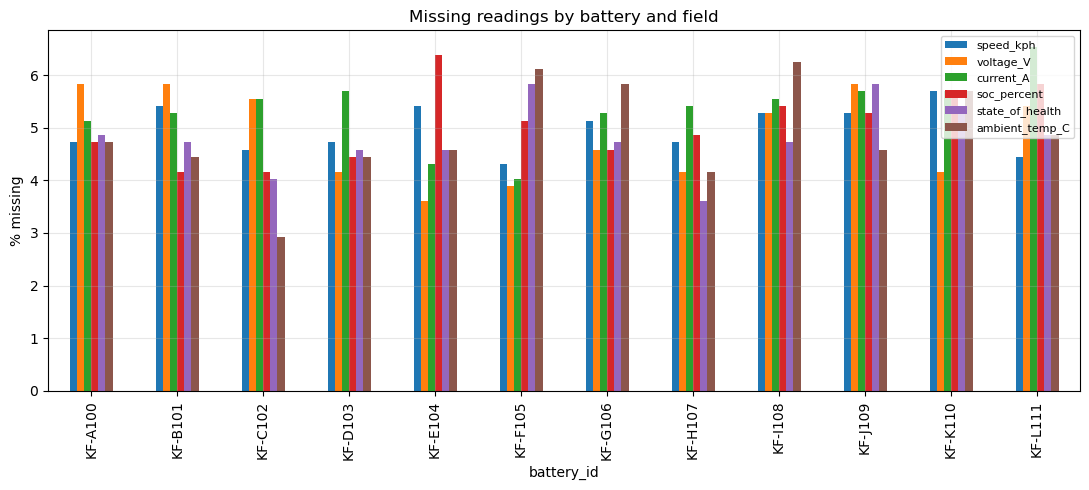

In [6]:
# Visualise missingness by battery, so we can see if dropout is uneven across the fleet
missing_by_battery = df.groupby('battery_id')[
    ['speed_kph', 'voltage_V', 'current_A', 'soc_percent', 'state_of_health', 'ambient_temp_C']
].apply(lambda x: x.isna().mean() * 100)

fig, ax = plt.subplots(figsize=(11, 5))
missing_by_battery.plot(kind='bar', ax=ax)
ax.set_ylabel('% missing')
ax.set_title('Missing readings by battery and field')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


In [7]:
# Impossible / out-of-range readings
issues = {
    'negative voltage': (df['voltage_V'] < 0).sum(),
    'negative current': (df['current_A'] < 0).sum(),
    'negative speed': (df['speed_kph'] < 0).sum(),
    'SOC below 0%': (df['soc_percent'] < 0).sum(),
    'SOC above 100%': (df['soc_percent'] > 100).sum(),
    'SOH below 0%': (df['state_of_health'] < 0).sum(),
    'SOH above 100%': (df['state_of_health'] > 100).sum(),
    'duplicate (timestamp, battery_id) rows': df.duplicated(subset=['timestamp', 'battery_id']).sum(),
}
pd.Series(issues, name='count')


negative voltage                          0
negative current                          0
negative speed                            0
SOC below 0%                              0
SOC above 100%                            0
SOH below 0%                              0
SOH above 100%                            0
duplicate (timestamp, battery_id) rows    0
Name: count, dtype: int64

In [8]:
# Reading cadence: are timestamps evenly spaced per battery, and do we see gaps (sensor dropout)?
gaps = (
    df.groupby('battery_id')['timestamp']
      .apply(lambda s: s.diff().dropna())
)
print("Most common interval between readings:", gaps.mode().iloc[0])
print("Largest gap observed:", gaps.max())


Most common interval between readings: 0 days 00:00:30
Largest gap observed: 0 days 00:00:30


**Takeaway:** no impossible readings (no negative voltage/current, no SOC/SOH outside
0-100%, no duplicate timestamps) — the missingness looks like random sensor dropout
(roughly ~5% per field) rather than a structural problem. Small gaps like this could be
linearly interpolated in a later Data Preparation step.


## 4. Fleet & state overview

Each reading is tagged with a `state`: `in_use` (riding), `charging`, or `not_in_use`
(idle). How is fleet time split, and does that split differ by battery?


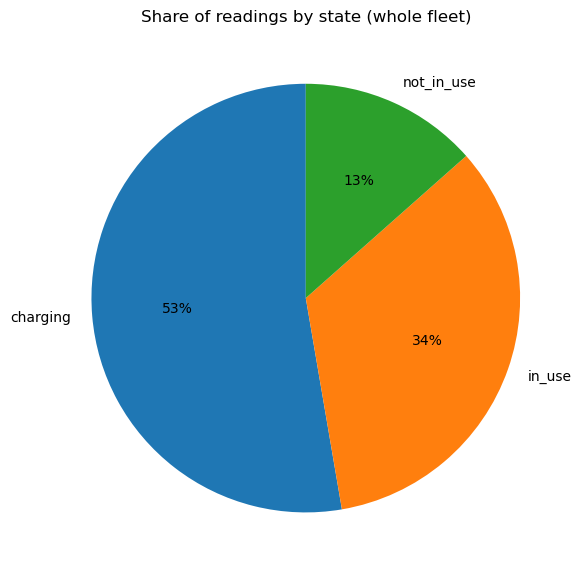

In [9]:
state_counts = df['state'].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(state_counts, labels=state_counts.index, autopct='%1.0f%%', startangle=90)
ax.set_title('Share of readings by state (whole fleet)')
plt.tight_layout()
plt.show()


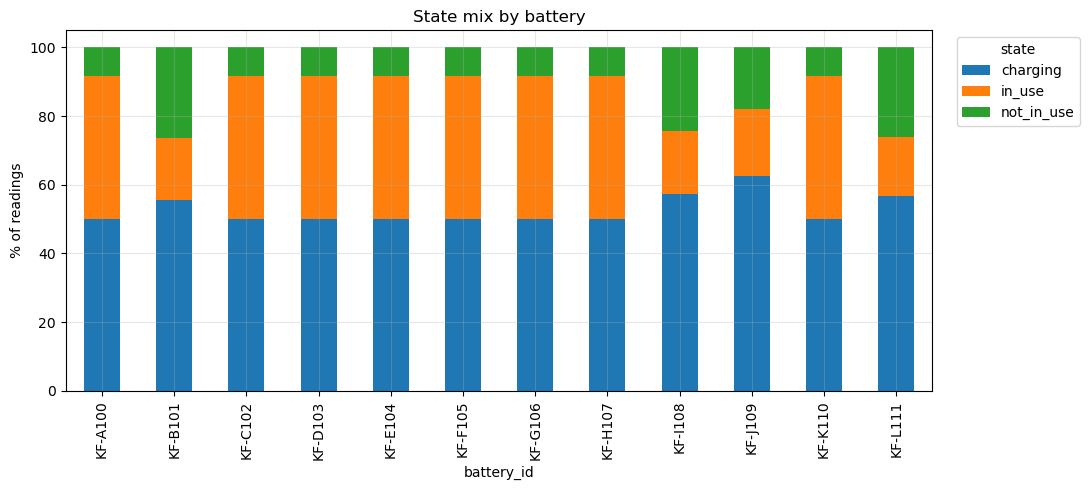

state,charging,in_use,not_in_use
battery_id,,,
KF-A100,360,300,60
KF-B101,401,129,190
KF-C102,360,300,60
KF-D103,360,300,60
KF-E104,360,300,60
KF-F105,360,300,60
KF-G106,360,300,60
KF-H107,360,300,60
KF-I108,413,132,175


In [10]:
state_by_battery = df.groupby(['battery_id', 'state']).size().unstack(fill_value=0)
state_by_battery_pct = state_by_battery.div(state_by_battery.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
state_by_battery_pct.plot(kind='bar', stacked=True, ax=ax)
ax.set_ylabel('% of readings')
ax.set_title('State mix by battery')
ax.legend(title='state', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
state_by_battery


Every reading is tagged in_use (riding), charging, or not_in_use (idle). The stacked bar chart shows most batteries split their time similarly, but four of them — B101, I108, J109, L111 — spend noticeably less time riding and more time charging/idle. That's a visual hint before we even look at health numbers.
Notice a handful of batteries spend noticeably less time
`in_use` and more time `charging`/`not_in_use` than the rest of the fleet — that's an early,
purely visual clue worth carrying into the SOH comparison below.


## 5. State of Health (SOH) by battery

`state_of_health` is a single self-reported value per battery (it doesn't change across a
battery's rows in this snapshot), so it acts as our ground-truth label for "how healthy is
this pack right now?"


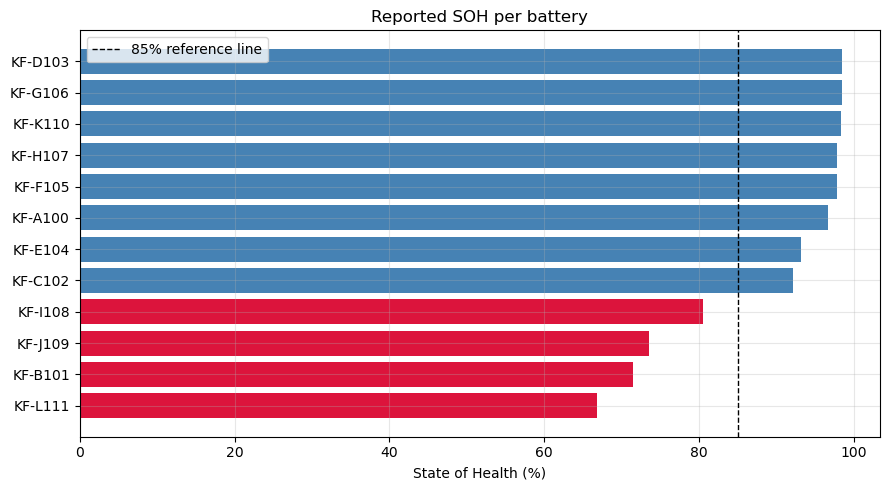

battery_id
KF-L111    66.851481
KF-B101    71.448506
KF-J109    73.520238
KF-I108    80.415094
KF-C102    92.133736
KF-E104    93.074652
KF-A100    96.633692
KF-F105    97.728052
KF-H107    97.806622
KF-K110    98.234235
KF-G106    98.361314
KF-D103    98.407328
Name: state_of_health, dtype: float64

In [11]:
soh_by_battery = df.groupby('battery_id')['state_of_health'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if v < 85 else 'steelblue' for v in soh_by_battery.values]
ax.barh(soh_by_battery.index, soh_by_battery.values, color=colors)
ax.axvline(85, color='black', linestyle='--', linewidth=1, label='85% reference line')
ax.set_xlabel('State of Health (%)')
ax.set_title('Reported SOH per battery')
ax.legend()
plt.tight_layout()
plt.show()

soh_by_battery


In [12]:
mean_soh, std_soh = soh_by_battery.mean(), soh_by_battery.std()
lower_ctrl = mean_soh - 2 * std_soh
print(f"Fleet mean SOH: {mean_soh:.1f}%  |  std: {std_soh:.1f}")
print(f"Illustrative mean − 2σ control limit: {lower_ctrl:.1f}%")
flagged = soh_by_battery[soh_by_battery < lower_ctrl]
print("\nBatteries below the mean-2σ line:")
flagged


Fleet mean SOH: 88.7%  |  std: 12.1
Illustrative mean − 2σ control limit: 64.5%

Batteries below the mean-2σ line:


Series([], Name: state_of_health, dtype: float64)

This mirrors the statistical-control-limit approach described in the project brief's
Modeling phase (mean ± 2 standard deviations, cross-checked with the 1.5× IQR rule) —
here applied just to SOH as a first, single-metric pass. A production version would combine
this with drain-rate slope, ride duration, and voltage-stability flags before treating a
battery as truly anomalous.


## 6. State of Charge (SOC) decay curves

Plotting SOC over time per battery is exactly the first EDA step called out in the brief:
*"plot SOC decay curves per battery ... look for batteries that stand out visually."*


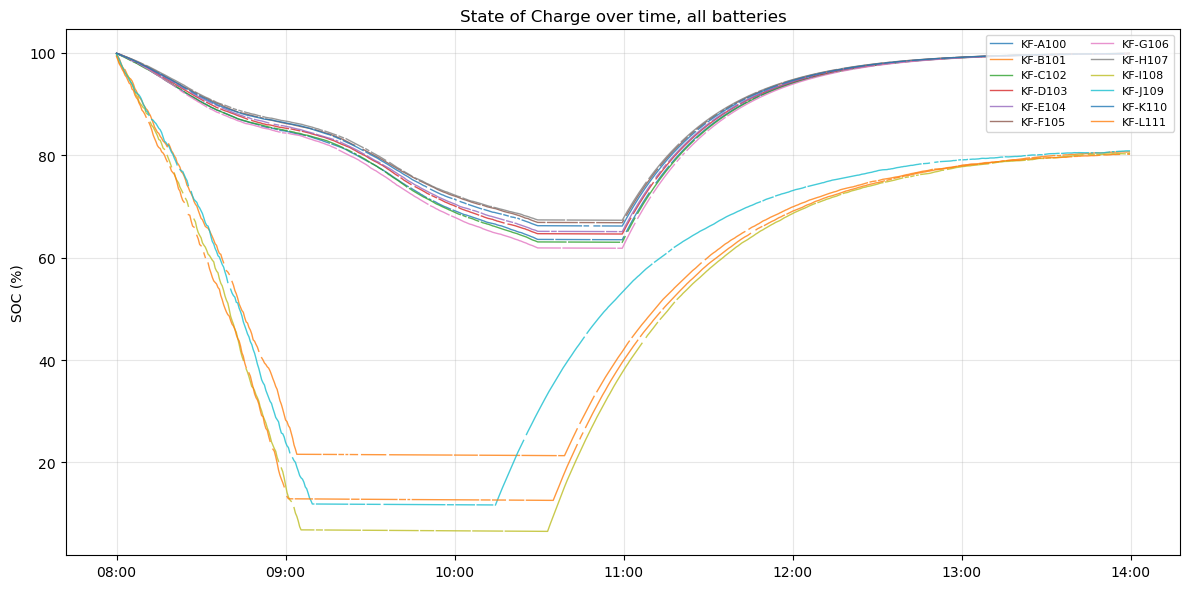

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
for bid, g in df.groupby('battery_id'):
    ax.plot(g['timestamp'], g['soc_percent'], label=bid, linewidth=1, alpha=0.8)
ax.set_ylabel('SOC (%)')
ax.set_title('State of Charge over time, all batteries')
ax.legend(loc='upper right', ncol=2, fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.show()


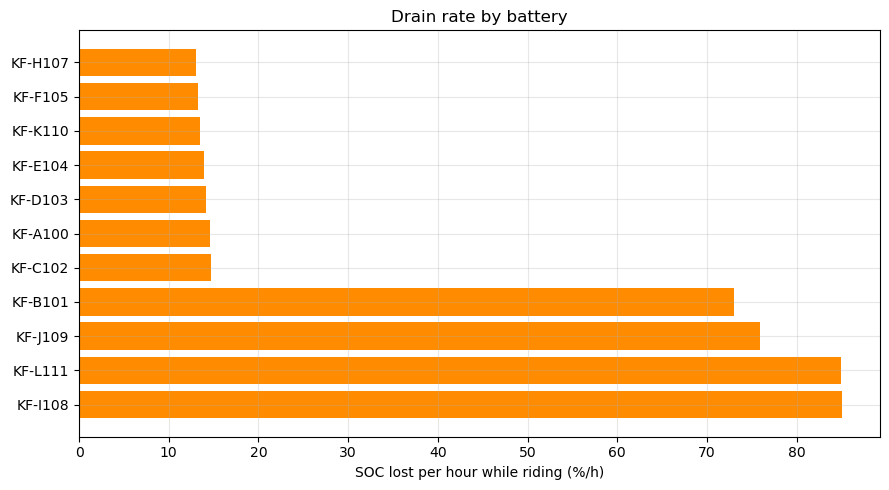

battery_id
KF-I108    85.051409
KF-L111    84.948432
KF-J109    75.880971
KF-B101    73.000951
KF-C102    14.758435
KF-A100    14.583858
KF-D103    14.136681
KF-E104    13.944443
KF-K110    13.515073
KF-F105    13.251755
KF-H107    13.057682
KF-G106          NaN
dtype: float64

In [14]:
# Drain rate while riding: %SOC lost per hour, only during in_use periods
def drain_rate(g):
    g = g[g['state'] == 'in_use'].sort_values('timestamp')
    if len(g) < 2:
        return np.nan
    dt_hours = (g['timestamp'].iloc[-1] - g['timestamp'].iloc[0]).total_seconds() / 3600
    d_soc = g['soc_percent'].iloc[0] - g['soc_percent'].iloc[-1]
    return d_soc / dt_hours if dt_hours > 0 else np.nan

drain = df.groupby('battery_id').apply(drain_rate, include_groups=False).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(drain.index, drain.values, color='darkorange')
ax.set_xlabel('SOC lost per hour while riding (%/h)')
ax.set_title('Drain rate by battery')
plt.tight_layout()
plt.show()

drain


## 7. Voltage & current behaviour

Voltage sag under load and current variability are classic health indicators — a tired
pack tends to show a wider voltage spread for the same current draw.


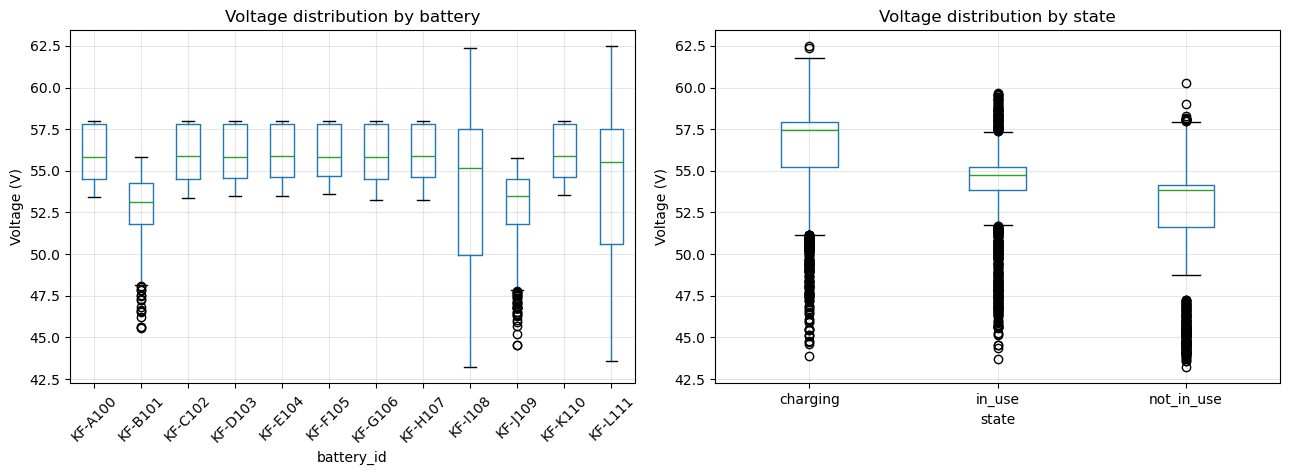

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df.boxplot(column='voltage_V', by='battery_id', ax=axes[0], rot=45)
axes[0].set_title('Voltage distribution by battery')
axes[0].set_ylabel('Voltage (V)')

df.boxplot(column='voltage_V', by='state', ax=axes[1])
axes[1].set_title('Voltage distribution by state')
axes[1].set_ylabel('Voltage (V)')

plt.suptitle('')
plt.tight_layout()
plt.show()


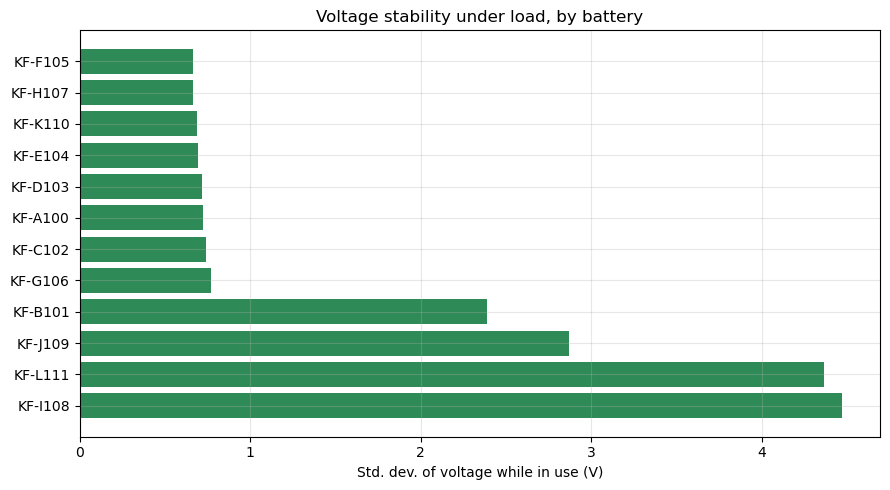

battery_id
KF-I108    4.467961
KF-L111    4.363314
KF-J109    2.866701
KF-B101    2.385361
KF-G106    0.767505
KF-C102    0.743532
KF-A100    0.724755
KF-D103    0.715422
KF-E104    0.694061
KF-K110    0.687347
KF-H107    0.665023
KF-F105    0.662240
Name: voltage_V, dtype: float64

In [16]:
voltage_std = df[df['state'] == 'in_use'].groupby('battery_id')['voltage_V'].std().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(voltage_std.index, voltage_std.values, color='seagreen')
ax.set_xlabel('Std. dev. of voltage while in use (V)')
ax.set_title('Voltage stability under load, by battery')
plt.tight_layout()
plt.show()

voltage_std


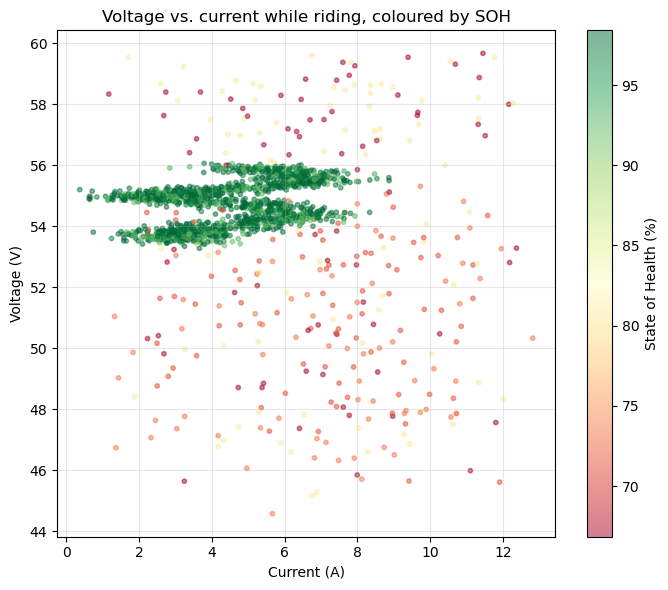

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
sample = df[df['state'] == 'in_use'].sample(min(2000, (df['state'] == 'in_use').sum()), random_state=0)
scatter = ax.scatter(sample['current_A'], sample['voltage_V'], c=sample['state_of_health'],
                      cmap='RdYlGn', alpha=0.5, s=10)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('State of Health (%)')
ax.set_xlabel('Current (A)')
ax.set_ylabel('Voltage (V)')
ax.set_title('Voltage vs. current while riding, coloured by SOH')
plt.tight_layout()
plt.show()


## 8. Ambient temperature effects

Tropical heat is called out in the brief as a stress factor. Let's see whether ambient
temperature correlates with voltage sag or drain rate.


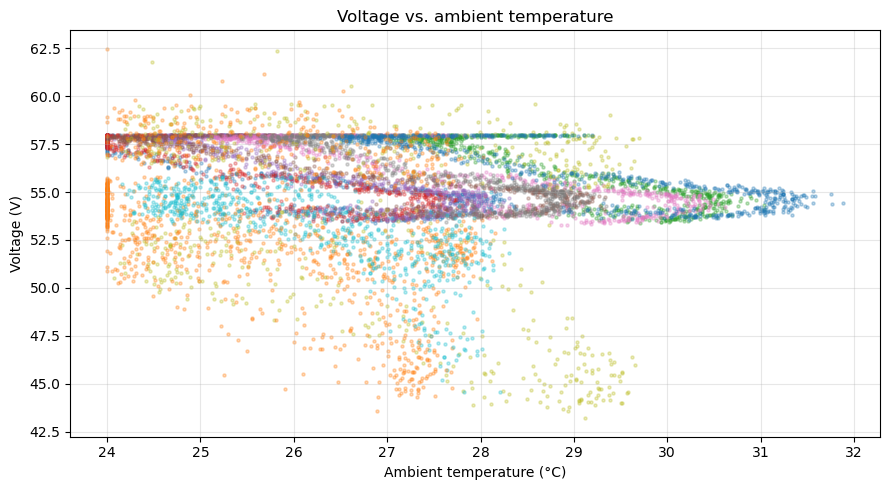

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
for bid, g in df.groupby('battery_id'):
    ax.scatter(g['ambient_temp_C'], g['voltage_V'], s=5, alpha=0.3, label=bid)
ax.set_xlabel('Ambient temperature (°C)')
ax.set_ylabel('Voltage (V)')
ax.set_title('Voltage vs. ambient temperature')
plt.tight_layout()
plt.show()


## 9. Correlations between numeric fields

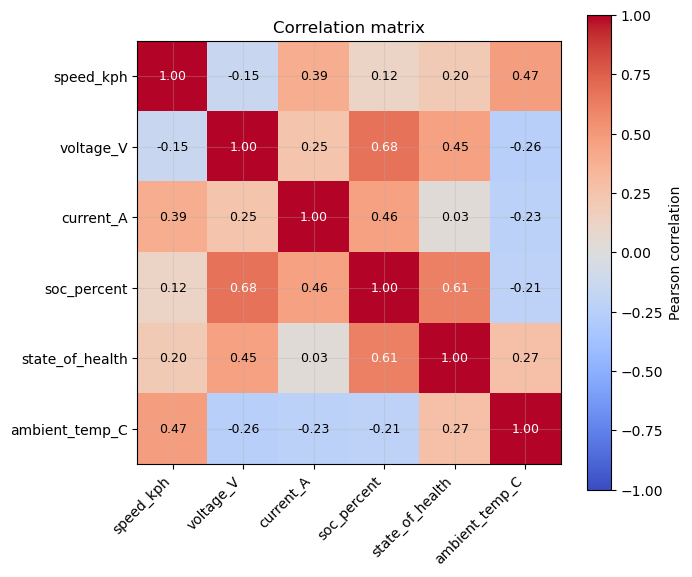

In [19]:
numeric_cols = ['speed_kph', 'voltage_V', 'current_A', 'soc_percent', 'state_of_health', 'ambient_temp_C']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black', fontsize=9)
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()


## 10. Summary of findings

- **Data quality**: no impossible readings (no negative voltage/current, SOC/SOH stay
  within 0-100%, no duplicate timestamps). Missingness is a modest, fairly even ~5% per
  field across the fleet — consistent with routine sensor dropout rather than a systemic
  issue. Small gaps could be linearly interpolated in Data Preparation.
- **State mix**: most batteries follow a similar riding/charging/idle split, but a
  minority spend noticeably less time `in_use` — worth checking against SOH and ride logs.
- **SOH**: reported SOH is not a continuum — a small cluster of batteries sits well below
  the rest of the fleet, echoing the "genuinely bimodal, well-separated split" the CRISP-DM
  brief treats as the signal that a screening model is ready to act on.
- **Drain rate & voltage stability**: the same lower-SOH batteries tend to show a
  faster SOC drain rate and/or a wider voltage spread under load — two of the four
  features the brief proposes engineering for the control-limit model.
- **Next step (Data Preparation)**: build the one-row-per-battery-per-session feature
  table (drain-rate slope, ride duration, voltage std. dev., reported SOH) that the brief
  specifies, ready for the mean±2σ / 1.5×IQR screening pass.

*(Edit any cell above and re-run to dig further into a specific battery or metric.)*
